### QUESTION BREAKDOWN

Evaluate the efficiency of the countires and its impact on sustainability. For this, we will be answering the following:
- Which countries produce more food with fewer environmental costs?
- Does higher efficiency lead to better sustainability scores?
- Are some countries efficient but unsustainable (or vice versa)?
- What food is produced the most by each country? Based on their efficiency and sustainability, should they produce other products?

### IMPORTS

In [29]:
!pip install imageio

In [142]:
# Core libraries
import numpy as np
import pandas as pd
import re
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.graph_objects as go
import plotly.io as pio
from matplotlib.animation import FuncAnimation
import matplotlib.ticker as ticker

# Widgets and display
import ipywidgets as widgets
from ipywidgets import HTML, HBox, VBox, GridBox
from IPython.display import display, clear_output, Markdown

# Data preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# I/O and requests
import requests
from io import StringIO
import plotly.graph_objects as go
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown
from ipywidgets import HTML, HBox, VBox, GridBox
import plotly.express as px
import imageio



#!pip install pycountry
import pycountry



In [143]:
!pip install anywidget

### HELPER FUNCTIONS

In [32]:
def fetch_oecd_data(api_url):
    """
    Fetches and parses OECD SDMX-JSON data from a given API URL and returns a clean DataFrame.

    Parameters:
        api_url (str): The full API URL for OECD SDMX-JSON data

    Returns:
        pd.DataFrame: Parsed data in tabular form
    """
    headers = {
        "Accept": "application/vnd.sdmx.data+json;version=1.0.0-wd"
    }

    response = requests.get(api_url, headers=headers)

    data = response.json()
    obs = data['data']['dataSets'][0]['observations']
    dimensions = data['data']['structure']['dimensions']['observation']

    dim_names = [d['name'] for d in dimensions]
    dim_values = [d['values'] for d in dimensions]

    records = []
    for key, val in obs.items():
        idx = list(map(int, key.split(":")))
        record = {dim_names[i]: dim_values[i][idx[i]]['name'] for i in range(len(idx))}
        record['value'] = val[0]
        records.append(record)

    return pd.DataFrame(records)

In [33]:
def plot_variable_trend(df, variable, top_n=25):
    """
    Draw a time trend chart of the specified variable by country (top N countries)

    Parameters:
        df (pd.DataFrame): DataFrame containing the data
        variable (str): The variable to plot
        top_n (int): Number of top countries to include in the plot

    Returns:
        None: Displays the plot
    """
    top_countries = df['Country'].value_counts().head(top_n).index.tolist()
    df_sub = df[df['Country'].isin(top_countries)]

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_sub, x='Year', y=variable, hue='Country', marker='o')
    plt.title(f"{variable} time trend")
    plt.ylabel(variable)
    plt.xlabel("Year")
    plt.legend(loc="center left", title="Country")
    plt.tight_layout()
    plt.show()

In [34]:
def safe_merge_on_country_year(df_main, df_to_merge, value_column, source_name):
    """
    Safely merges an external dataset into the main DataFrame using 'Country' and 'Year'.

    Parameters:
    - df_main: pd.DataFrame, the main dataset
    - df_to_merge: pd.DataFrame, dataset to merge in
    - value_column: str, column in df_to_merge to bring into df_main
    - source_name: str, label to append for the new column (e.g. 'OECD', 'FAO')

    Returns:
    - pd.DataFrame with the merged column added
    """

    df_main['Country'] = df_main['Country'].astype(str)
    df_main['Year'] = df_main['Year'].astype(int)

    df_to_merge = df_to_merge.rename(columns={
        'Country': 'Country',
        'Year': 'Year',
        value_column: f"{value_column} [{source_name}]"
    })
    df_to_merge['Country'] = df_to_merge['Country'].astype(str)
    df_to_merge['Year'] = df_to_merge['Year'].astype(int)

    merged = df_main.merge(
        df_to_merge[['Country', 'Year', f"{value_column} [{source_name}]"]],
        on=['Country', 'Year'],
        how='left',
        validate='1:1'  # Ensures no duplicates sneak in
    )

    return merged

In [35]:
def plot_missing_by_year(df, numerical_columns):
    """
    Plot a heatmap of missing data by year for the specified numerical columns.

    Parameters:
    - df: pd.DataFrame, the dataset to analyze
    - numerical_columns: list of str, the numerical columns to check for missing data

    Returns:
    - None, but displays a heatmap of missing data
    """
    missing_by_year = df.groupby("Year")[numerical_columns].apply(lambda x: x.isnull().mean())
    plt.figure(figsize=(16, 6))
    sns.heatmap(missing_by_year.T, cmap="Reds", cbar_kws={'label': 'Fraction Missing'})
    plt.title("Missing Data Matrix by Year (Red = More Missing)")
    plt.xlabel("Year")
    plt.ylabel("Numerical Variables")
    plt.tight_layout()
    plt.show()

In [36]:
def missing_percent_by_variable(df, columns):
    """
    Calculates the percentage of missing values for each specified column.
    """
    missing_percent = df[columns].isnull().mean().sort_values(ascending=False) * 100
    return missing_percent.reset_index().rename(columns={'index': 'Variable', 0: '% Missing'})

In [37]:
def drop_columns_with_missing(df, columns, threshold, verbose):
    """
    Drops columns from the DataFrame if missingness exceeds the specified threshold.

    Parameters:
    - df: DataFrame to evaluate
    - columns: list of columns to check (default = all)
    - threshold: maximum allowed fraction of missing values (0-1)
    - verbose: if True, prints a summary of dropped columns

    Returns:
    - df_reduced: DataFrame with columns dropped
    - kept_columns: list of columns retained
    - dropped_columns: list of columns removed
    """
    if columns is None:
        columns = df.columns.tolist()

    missing_frac = df[columns].isnull().mean()
    dropped_columns = missing_frac[missing_frac > threshold].index.tolist()
    kept_columns = missing_frac[missing_frac <= threshold].index.tolist()

    df_reduced = df.drop(columns=dropped_columns)

    if verbose:
        print(f"Threshold = {threshold:.0%}")
        print(f"Kept columns: {len(kept_columns)}: {kept_columns}")
        print(f"Dropped columns ({len(dropped_columns)}): {dropped_columns}")

    return df_reduced, kept_columns, dropped_columns

In [38]:
def filter_countries_with_most_data(df, group_col='Country', threshold=10):
    """
    Filters the DataFrame to keep only countries with low missing values across variables.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        group_col (str): Column representing countries.
        threshold (float): Maximum missing value % allowed per variable.

    Returns:
        tuple:
            - Filtered DataFrame with selected countries.
            - DataFrame of missing % per variable for selected countries.
    """
    # Step 1: Calculate missing % per variable per country
    grouped = df.groupby(group_col, group_keys=False)
    missing_counts = grouped.apply(lambda g: g.drop(columns=group_col, errors='ignore').isnull().sum())
    total_counts = grouped.size()

    total_df = pd.DataFrame(index=missing_counts.index, columns=missing_counts.columns)
    for col in total_df.columns:
        total_df[col] = total_counts
    missing_pct = (missing_counts / total_df) * 100

    # Step 2: Keep only countries with all variables under threshold
    good_countries = missing_pct[missing_pct.le(threshold).all(axis=1)].index.tolist()

    # Step 3: Filter original DataFrame
    filtered_df = df[df[group_col].isin(good_countries)].copy()

    # Step 4: Recalculate missing % on filtered set
    grouped_filtered = filtered_df.groupby(group_col, group_keys=False)
    updated_missing = grouped_filtered.apply(lambda g: g.drop(columns=group_col, errors='ignore').isnull().sum())
    updated_total = grouped_filtered.size()

    updated_total_df = pd.DataFrame(index=updated_missing.index, columns=updated_missing.columns)
    for col in updated_total_df.columns:
        updated_total_df[col] = updated_total

    updated_missing_pct = (updated_missing / updated_total_df) * 100

    # Drop group_col from columns if duplicated
    if group_col in updated_missing_pct.columns:
        updated_missing_pct = updated_missing_pct.drop(columns=group_col)

    return filtered_df, updated_missing_pct.reset_index()

In [39]:
def plot_missing_by_year_and_country(df, numerical_columns, country_name):
    """
    Plot a heatmap of missing data by year for the specified numerical columns, filtered by a specific country.

    Parameters:
    - df: pandas DataFrame containing the data.
    - numerical_columns: list of numerical column names to assess.
    - country_name: string, the name of the country to filter for.
    """
    # Filter by country
    df_country = df[df["Country"] == country_name]

    # Calculate missing data fraction by year
    missing_by_year = df_country.groupby("Year")[numerical_columns].apply(lambda x: x.isnull().mean())

    # Plot heatmap
    plt.figure(figsize=(16, 6))
    sns.heatmap(missing_by_year.T, cmap="Reds", cbar_kws={'label': 'Fraction Missing'})
    plt.title(f"Missing Data Matrix by Year for {country_name} (Red = More Missing)")
    plt.xlabel("Year")
    plt.ylabel("Numerical Variables")
    plt.tight_layout()
    plt.show()

In [40]:
def plot_missing_by_country(df, numerical_columns, top_n=20):
    """
    Visualize, for each country, the fraction of missing values
    across the given numerical columns—and highlight the worst offenders.

    Parameters:
        df (pd.DataFrame): must include a 'Country' column.
        numerical_columns (List[str]): which numeric fields to check.
        top_n (int): show only the top N countries ranked by missing rate.
    """
    # Compute missing fraction per country & column
    miss_frac = (
        df.groupby("Country")[numerical_columns]
          .apply(lambda sub: sub.isnull().mean())
    )

    # Identify the top N countries by overall missingness
    overall = miss_frac.mean(axis=1)
    worst = overall.nlargest(top_n).index
    data = miss_frac.loc[worst]

    # Plot
    plt.figure(figsize=(12, max(6, 0.3*len(worst))))
    sns.heatmap(
        data,
        cmap="Reds",
        cbar_kws={'label': 'Fraction Missing'},
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Missing‐Data Heatmap by Country (Top {top_n})")
    plt.xlabel("Variables")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()


In [41]:
def generate_equal_weights(weight_dict):
    """
    Generate equal weights from a given weight dictionary.

    Args:
        weight_dict (dict): Dictionary with keys as indicators.

    Returns:
        dict: Dictionary with equal weights.
    """
    return {col: 1 / len(weight_dict) for col in weight_dict}

In [42]:
def plot_pca_and_loadings(df_scaled, weight_dict):
    """
    Run PCA on scaled variables and plot variance explained and loadings.

    Args:
        df_scaled (pd.DataFrame): DataFrame with scaled indicators.
        weight_dict (dict): Weights dict indicating which columns to include.

    Returns:
        pd.DataFrame: PCA loadings for PC1–PC3.
    """
    X = df_scaled[list(weight_dict.keys())]
    X_std = StandardScaler().fit_transform(X)

    pca = PCA()
    pca.fit(X_std)

    explained_var = pca.explained_variance_ratio_

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o')
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance')
    plt.title('PCA - Variance Explained')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    loadings_df = pd.DataFrame({
        'PC1': pd.Series(pca.components_[0], index=X.columns),
        'PC2': pd.Series(pca.components_[1], index=X.columns),
        'PC3': pd.Series(pca.components_[2], index=X.columns)
    })

    loadings_df.plot(kind='bar', figsize=(10, 5))
    plt.title('Loadings of Variables on Principal Components 1–3')
    plt.ylabel('Loading')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return loadings_df

In [43]:
def vary_weight(weights_dict, target_var, delta):
    """
    Modify one weight by delta and normalize the rest.

    Args:
        weights_dict (dict): original weights
        target_var (str): variable to adjust
        delta (float): amount to adjust target_var by (e.g. +0.05)

    Returns:
        dict: new normalized weight dict
    """
    new_weights = weights_dict.copy()
    new_weights[target_var] += delta
    total = sum(new_weights.values())
    return {k: v / total for k, v in new_weights.items()}

In [44]:
def vary_weight(weights_dict, target_var, delta):
    """
    Modify one weight by delta and normalize the rest.

    Args:
        weights_dict (dict): original weights
        target_var (str): variable to adjust
        delta (float): amount to adjust target_var by (e.g. +0.05)

    Returns:
        dict: new normalized weight dict
    """
    new_weights = weights_dict.copy()
    new_weights[target_var] += delta
    total = sum(new_weights.values())
    return {k: v / total for k, v in new_weights.items()}

def compute_efficiency_score(df, weights):
    """
    Compute efficiency score using weighted sum.

    Parameters:
        df (pd.DataFrame): DataFrame with scaled indicators.
        weights (dict): Dictionary of weights for each indicator.
    Returns:
        pd.Series: Efficiency score for each row in the DataFrame.

    """
    return df[list(weights.keys())].dot(pd.Series(weights))

def run_efficiency_sensitivity(df_scaled, weights_efficiency, deltas=[-0.10, -0.05, -0.01, 0.01, 0.05, 0.10]):
    """
    Perform sensitivity analysis on efficiency weights.

    Parameters:
        df_scaled (pd.DataFrame): DataFrame with scaled indicators.
        weights_efficiency (dict): Dictionary of weights for each indicator.
        deltas (list): List of deltas to apply to the weights.
    Returns:
        pd.DataFrame: DataFrame with rank changes for each country and variable.
    """
    results = []

    df_scaled['eff_score'] = compute_efficiency_score(df_scaled, weights_efficiency)

    for var in weights_efficiency:
        for delta in deltas:
            new_weights = vary_weight(weights_efficiency, var, delta)
            if new_weights is None:
                continue

            new_score = compute_efficiency_score(df_scaled, new_weights)
            rank_original = df_scaled['eff_score'].rank(ascending=False)
            rank_new = new_score.rank(ascending=False)
            rank_change = (rank_original - rank_new).abs()

            for country, change in zip(df_scaled['Country'], rank_change):
                results.append({
                    'Country': country,
                    'Variable': var,
                    'Delta': delta,
                    'Rank_Change': change
                })

    return pd.DataFrame(results)

In [45]:
def compute_pca_weights(loadings, original_weights, pc='PC1'):
    """
    Given PCA loadings and original weights, compute PCA-derived weights
    and compare them with the originals.
    """
    # Step 1: Compute absolute loadings for the first principal component
    pc_loadings = loadings[pc].abs()

    # Step 2: Normalize loadings to form PCA weights
    pca_weights = pc_loadings / pc_loadings.sum()

    # Step 3: Align original weights with PCA weights
    original_weights_series = pd.Series(original_weights)

    # Step 4: Build comparison DataFrame
    weights_comparison = pd.DataFrame({
        'PCA Weights': pca_weights,
        'Original Weights': original_weights_series
    })
    weights_comparison["Difference"] = weights_comparison["PCA Weights"] - weights_comparison["Original Weights"]

    # Step 5: Sort by PCA importance
    weights_comparison = weights_comparison.sort_values(by="PCA Weights", ascending=False)

    # Step 6: Return both the new dictionary and the comparison table
    return weights_comparison, pca_weights.to_dict()

In [46]:
def create_animated_bar_chart(df, value_col, title, color_map, label, height=1000, width=900):
    """
    Create an animated horizontal bar chart with color shading based on values.

    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        value_col (str): Column name for the values to be plotted.
        title (str): Title of the chart.
        color_map (str): Color map for shading.
        label (str): Label for the x-axis.
        height (int): Height of the chart.
        width (int): Width of the chart.
    Returns:
        plotly.graph_objects.Figure: Animated bar chart figure.
    """
    df_grouped = df[['Country', 'Year', value_col]].groupby(['Year', 'Country'], as_index=False).mean()
    years = sorted(df_grouped['Year'].unique())
    countries = sorted(df_grouped['Country'].unique())

    df_pivot = df_grouped.pivot(index='Country', columns='Year', values=value_col).reindex(countries)

    # Color mapping
    norm = mcolors.Normalize(vmin=df_pivot.min().min(), vmax=df_pivot.max().max())
    cmap = cm.get_cmap(color_map)

    def get_colors(values):
        return [mcolors.to_hex(cmap(norm(v))) for v in values]

    # Initial trace
    initial_values = df_pivot[years[0]]
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=initial_values,
        y=countries,
        orientation='h',
        marker_color=get_colors(initial_values),
        text=[f"{v:.2f}" for v in initial_values],
        textposition='outside',
        name=label,
        hovertemplate='Country: %{y}<br>Score: %{x:.2f}<extra></extra>'
    ))

    # Frames for animation
    frames = [
        go.Frame(
            data=[go.Bar(
                x=df_pivot[year],
                y=countries,
                text=[f"{v:.2f}" for v in df_pivot[year]],
                marker_color=get_colors(df_pivot[year])
            )],
            name=str(year)
        ) for year in years
    ]
    fig.frames = frames

    # Layout with controls
    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor='center'),
        xaxis_title=label,
        yaxis=dict(categoryorder='array', categoryarray=countries),
        xaxis=dict(range=[0, df_pivot.max().max() * 1.1]),
        height=height,
        width=width,
        bargap=0.35,
        font=dict(size=14),
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="▶ Play", method="animate", args=[None, {
                "frame": {"duration": 700, "redraw": True},
                "fromcurrent": True
            }])],
            showactive=False,
            x=0.1,
            y=1.1
        )],
        sliders=[dict(
            steps=[dict(method="animate", args=[[str(year)], {
                "frame": {"duration": 500, "redraw": True},
                "mode": "immediate"
            }], label=str(year)) for year in years],
            active=0,
            x=0.1,
            y=-0.1,
            len=0.9
        )]
    )
    return fig


In [47]:
# Define common color map
COLORS = {
    'Energy': '#EF553B',
    'Water': '#00CC96',
    'Pesticides': '#636EFA',
    'Emissions': '#AB63FA',
    'Phosphorus': '#19D3F3',
    'Nitrogen': '#FFA15A'
}

def build_frames(df, components, countries, years, colors, cols=5):
    frames = []
    for year in years:
        data = []
        for country in countries:
            row = df[(df['Country'] == country) & (df['Year'] == year)]
            if row.empty: continue
            row = row.iloc[0]
            labels, values, color_list = [], [], []
            for label, (col, weight) in components.items():
                labels.append(label)
                values.append(row[col] * weight)
                color_list.append(colors[label])
            index = countries.index(country)
            pie = go.Pie(labels=labels, values=values, name=country, title=country,
                         hole=0.4, marker=dict(colors=color_list),
                         legendgroup="country", showlegend=False,
                         domain=dict(row=index // cols, column=index % cols))
            data.append(pie)
        frames.append(go.Frame(data=data, name=str(year)))
    return frames

def build_initial_data(df, components, countries, init_year, colors, cols=5):
    init_data = []
    for country in countries:
        row = df[(df['Country'] == country) & (df['Year'] == init_year)]
        if row.empty: continue
        row = row.iloc[0]
        labels, values, color_list = [], [], []
        for label, (col, weight) in components.items():
            labels.append(label)
            values.append(row[col] * weight)
            color_list.append(colors[label])
        index = countries.index(country)
        pie = go.Pie(labels=labels, values=values, name=country, title=country,
                     hole=0.4, marker=dict(colors=color_list),
                     legendgroup="shared'",
                     showlegend=True,
                     domain=dict(row=index // cols, column=index % cols))
        init_data.append(pie)
    return init_data

def generate_pie_animation(df, components, title, output_path, colors=COLORS, cols=5):
    years = sorted(df['Year'].unique())
    countries = sorted(df['Country'].unique())
    frames = build_frames(df, components, countries, years, colors, cols)
    init_data = build_initial_data(df, components, countries, years[0], colors, cols)

    fig = go.Figure(
        data=init_data,
        frames=frames,
        layout=go.Layout(
            title=title,
            updatemenus=[dict(
                type="buttons",
                showactive=False,
                buttons=[
                    dict(label="Play", method="animate", args=[None, {"frame": {"duration": 1000}, "fromcurrent": True}]),
                    dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0}, "mode": "immediate"}])
                ]
            )],
            sliders=[dict(
                steps=[dict(method='animate',
                            args=[[str(year)], dict(mode='immediate', frame=dict(duration=800), transition=dict(duration=0))],
                            label=str(year)) for year in years],
                transition=dict(duration=0),
                x=0.1, xanchor="left", y=0, yanchor="top"
            )],
            grid=dict(rows=(len(init_data) + cols - 1) // cols, columns=cols),
            height=300 * ((len(init_data) + cols - 1) // cols)
        )
    )

    # Save to HTML
    pio.write_html(fig, output_path, auto_play=False)

    return output_path

### LOADING DATA

In [48]:
df = pd.read_csv("/content/data_full_5.csv")

### HANDLING NULL VALUES PART 1 - USE COUNTIRES WITH MOST INFO

In [49]:
numerical_columns = df.select_dtypes(include='number').columns

In [50]:
df["Country"].unique()

array(['Argentina', 'Australia', 'Austria', 'Belgium', 'Brazil',
       'Bulgaria', 'Canada', 'Chile', 'China (People’s Republic of)',
       'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czechia',
       'Denmark', 'Developed countries', 'Developing countries', 'Egypt',
       'Estonia', 'Ethiopia', 'Finland', 'Flemish Region', 'France',
       'Germany', 'Greece', 'Hungary', 'Iceland', 'India', 'Indonesia',
       'Iran', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kazakhstan',
       'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta',
       'Mexico', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway',
       'Pakistan', 'Paraguay', 'Peru', 'Philippines', 'Poland',
       'Portugal', 'Romania', 'Russia', 'Saudi Arabia', 'Slovak Republic',
       'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland',
       'Thailand', 'Türkiye', 'Ukraine', 'United Kingdom',
       'United States', 'Viet Nam', 'Wallonia'], dtype=object)

In [51]:
df["Country"].nunique()

68

<ipython-input-52-7fa4f4a3a179>:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


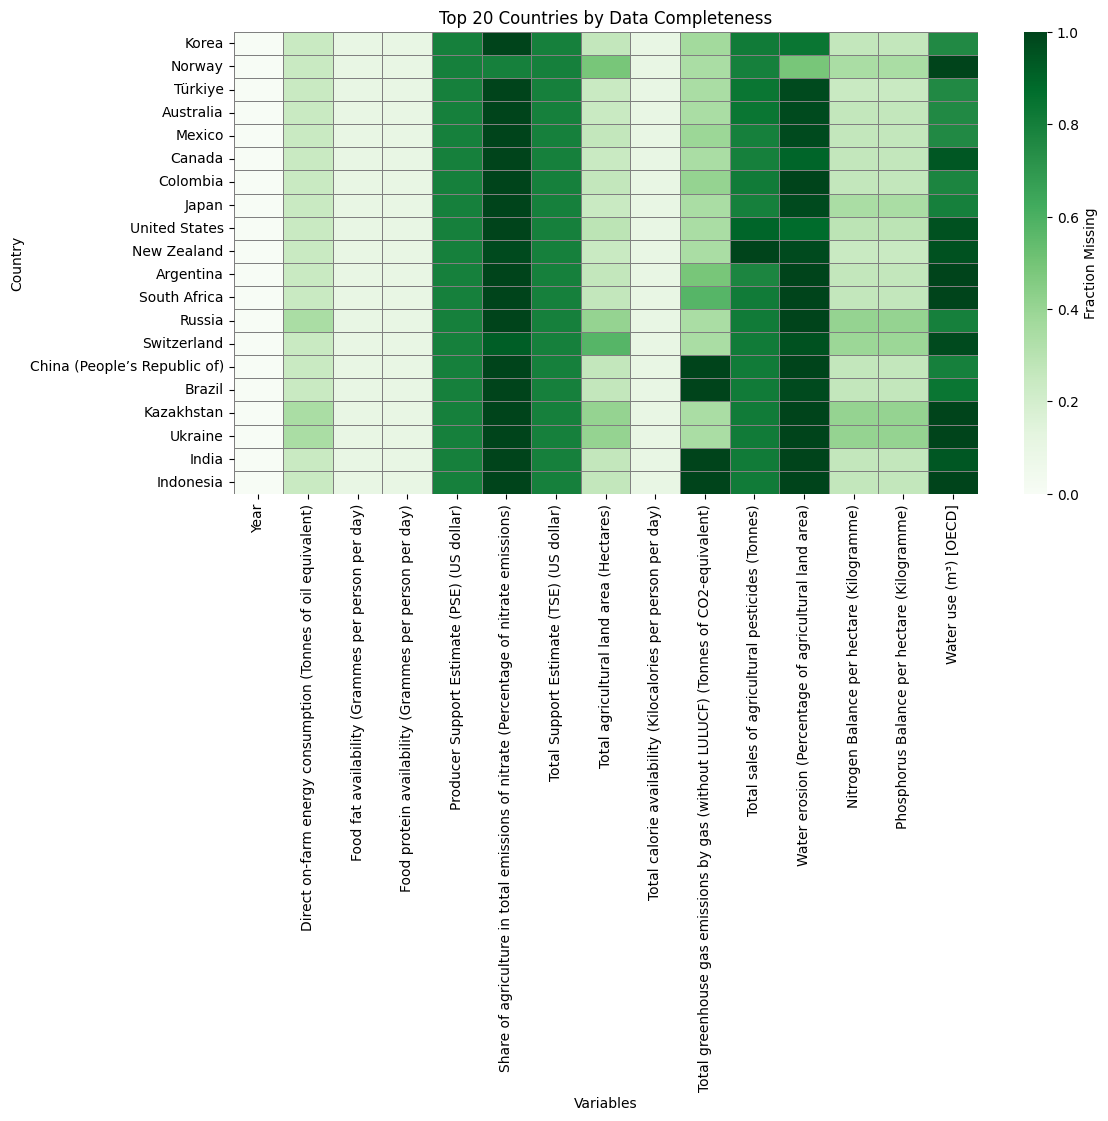

In [52]:
# Parameters
top_n = 20

# Calculate missing fraction per variable per country
missing_fraction = df.groupby("Country")[numerical_columns].apply(lambda x: x.isnull().mean())

# Compute average missing fraction per country
country_avg_missing = missing_fraction.mean(axis=1)

# Select top N countries with least missing data
best_countries = country_avg_missing.nsmallest(top_n).index
data_best = missing_fraction.loc[best_countries]

# Plot heatmap
plt.figure(figsize=(12, max(6, 0.3 * len(best_countries))))
sns.heatmap(
    data_best,
    cmap="Greens",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Fraction Missing'}
)
plt.title(f"Top {top_n} Countries by Data Completeness")
plt.xlabel("Variables")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [53]:
# filter data based on best countiries to keep
df_countires_best = df[df["Country"].isin(best_countries)].copy()

Hence, we have narrowed down the companies we can use for our analysis. From 68 to 20.

In [54]:
df_countires_best["Country"].unique(), df_countires_best["Country"].nunique()

(array(['Argentina', 'Australia', 'Brazil', 'Canada',
        'China (People’s Republic of)', 'Colombia', 'India', 'Indonesia',
        'Japan', 'Kazakhstan', 'Korea', 'Mexico', 'New Zealand', 'Norway',
        'Russia', 'South Africa', 'Switzerland', 'Türkiye', 'Ukraine',
        'United States'], dtype=object),
 20)

### HANDLING NULL VALUES PART 2 - USE YEARS WITH MOST INFO

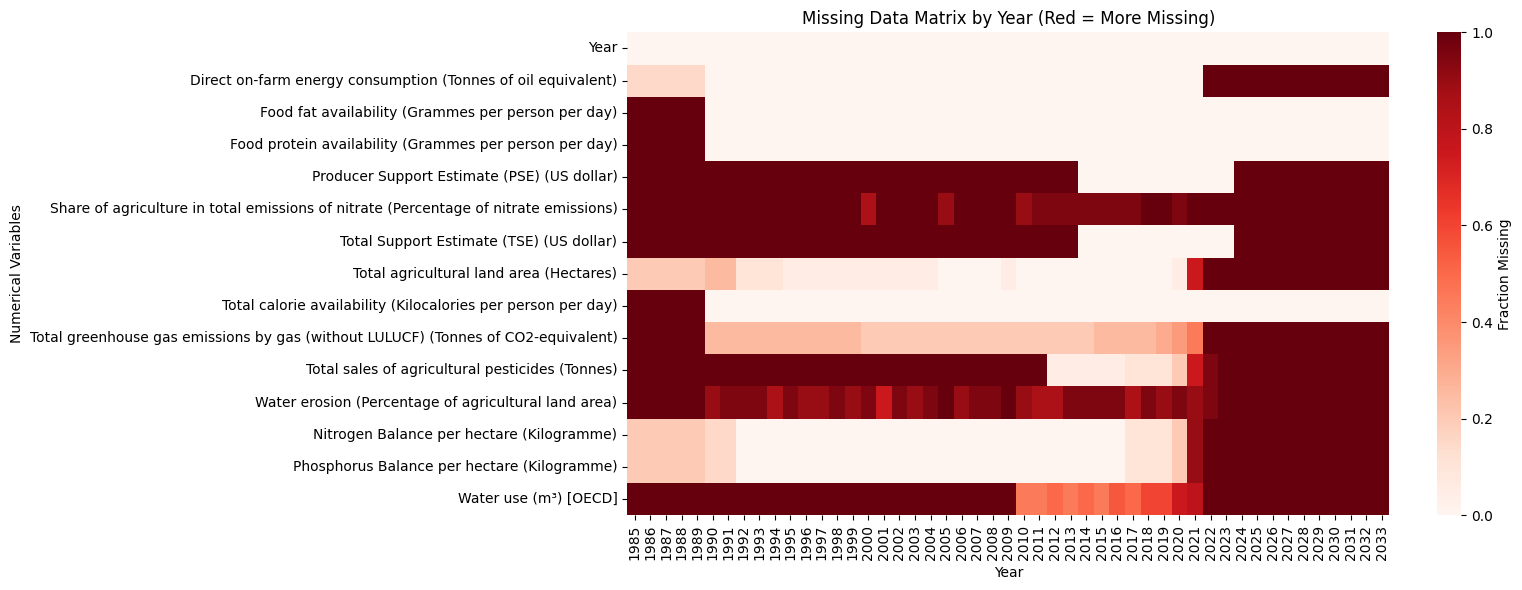

In [55]:
plot_missing_by_year(df_countires_best, numerical_columns)

Below we are also filtering the data based on the years with more information.

In [56]:
df_time_best = df_countires_best[df_countires_best['Year'].between(2012, 2020)].copy()

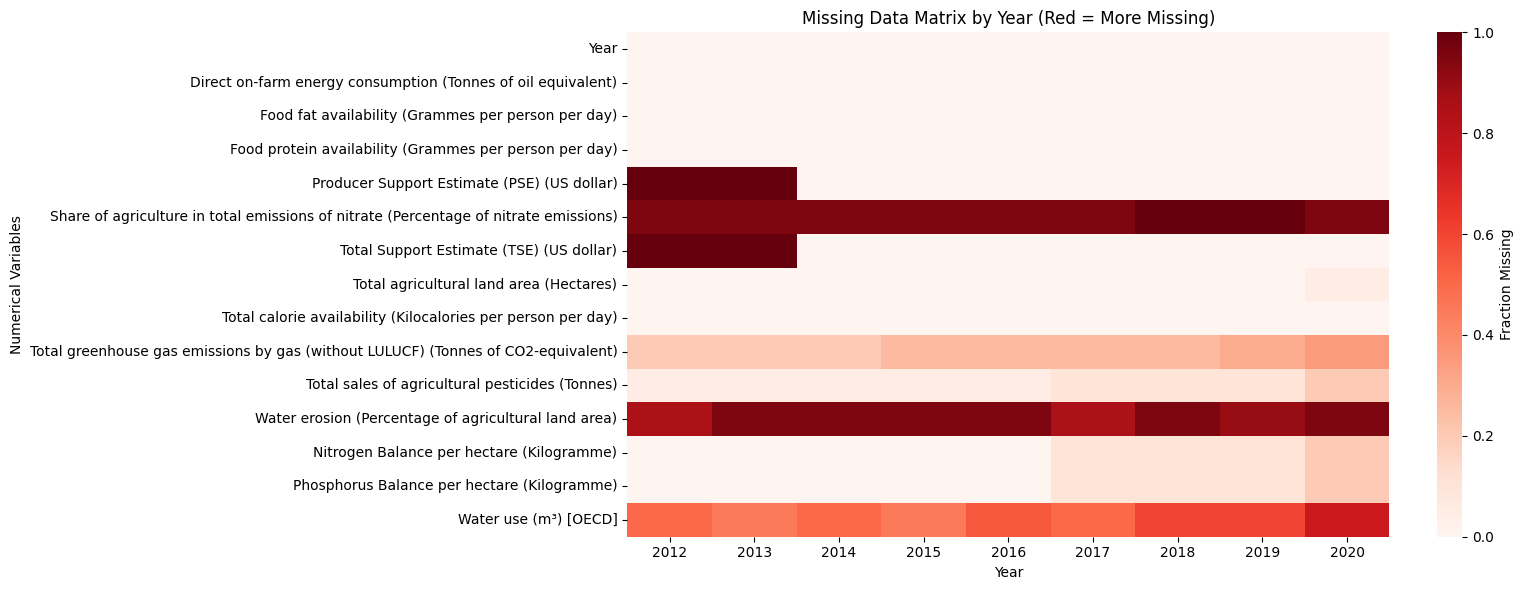

In [57]:
plot_missing_by_year(df_time_best, numerical_columns)

As it can be seen in this heatmap, we now have a dataset with a low fraction of missing values we can work with.

In [58]:
df_time_best.isnull().mean().sort_values(ascending=False) * 100

,0
Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions),96.111111
Water erosion (Percentage of agricultural land area),92.222222
Water use (m³) [OECD],54.444444
Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent),25.000000
Total Support Estimate (TSE) (US dollar),22.222222
Producer Support Estimate (PSE) (US dollar),22.222222
Total sales of agricultural pesticides (Tonnes),8.333333
Phosphorus Balance per hectare (Kilogramme),5.555556
Nitrogen Balance per hectare (Kilogramme),5.555556
Total agricultural land area (Hectares),0.555556


Based on this percentages of missing values, we can drop those with a value surpassing a threhold of our choosing.

In [59]:
df_reduced, kept_columns, dropped_columns = drop_columns_with_missing(df_time_best, columns=numerical_columns, threshold=0.60,verbose=True)

Threshold = 60%
Kept columns: 13: ['Year', 'Direct on-farm energy consumption (Tonnes of oil equivalent)', 'Food fat availability (Grammes per person per day)', 'Food protein availability (Grammes per person per day)', 'Producer Support Estimate (PSE) (US dollar)', 'Total Support Estimate (TSE) (US dollar)', 'Total agricultural land area (Hectares)', 'Total calorie availability (Kilocalories per person per day)', 'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)', 'Total sales of agricultural pesticides (Tonnes)', 'Nitrogen Balance per hectare (Kilogramme)', 'Phosphorus Balance per hectare (Kilogramme)', 'Water use (m³) [OECD]']
Dropped columns (2): ['Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions)', 'Water erosion (Percentage of agricultural land area)']


### IMPUTATION OF KEPT FEATURES

In [60]:
df_reduced[kept_columns] = df_reduced[kept_columns].fillna(df_reduced[kept_columns].median())

### SCORES DEFINITION  & CALCULATION

To assess both agricultural efficiency and sustainability, we can define two complementary scores:
- an efficiency score that captures how effectively resources are converted into agricultural output
- a sustainability score that reflects the environmental impact associated with that output.

The agricultural efficiency score is defined as the ratio of agricultural output to the total resource inputs required to produce it. In this context, agricultural output can be represented by indicators such as total calorie availability per person per day or food protein availability. These serve as proxies for how much food is being produced. The inputs, on the other hand, include land area used for agriculture, water withdrawal, nitrogen and phosphorus fertilizer balances, greenhouse gas emissions, and pesticide use. Since these inputs are measured in different units and magnitudes (e.g., hectares, cubic meters, tonnes), they are first normalized using min-max scaling. The efficiency score is then calculated by dividing the normalized food output by the sum of normalized input values. A higher score indicates a system that delivers more food with fewer resources — i.e., more efficient.

The sustainability score evaluates the environmental cost of agricultural production by relating food output to the level of ecological pressure it generates. This ecological pressure is quantified through a resource pressure index, which aggregates the normalized values of environmental stressors such as emissions, fertilizer overuse, land and water use, and erosion — weighted according to their relative environmental impact. The sustainability score is calculated by dividing the normalized calorie availability by this pressure index. A higher sustainability score means the system produces food with less environmental harm, and thus is more sustainable.

In [61]:
# Step 1: Copy the cleaned and imputed data
df = df_reduced.copy()

# Step 2: Create output-per-input efficiency ratios
df['calories_per_kgN'] = df['Total calorie availability (Kilocalories per person per day)'] / (df['Nitrogen Balance per hectare (Kilogramme)'] + 1e-6)
df['calories_per_kgP'] = df['Total calorie availability (Kilocalories per person per day)'] / (df['Phosphorus Balance per hectare (Kilogramme)'] + 1e-6)
df['calories_per_water'] = df['Total calorie availability (Kilocalories per person per day)'] / (df['Water use (m³) [OECD]'] + 1e-6)
df['calories_per_emission'] = df['Total calorie availability (Kilocalories per person per day)'] / (df['Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)'] + 1e-6)
df['calories_per_energy'] = df['Total calorie availability (Kilocalories per person per day)'] / (df['Direct on-farm energy consumption (Tonnes of oil equivalent)'] + 1e-6)

# Step 3: Scale efficiency metrics to [0, 1]
efficiency_vars = [
    'calories_per_kgN',
    'calories_per_kgP',
    'calories_per_water',
    'calories_per_emission',
    'calories_per_energy'
]

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[[f"{c}_scaled" for c in efficiency_vars]] = scaler.fit_transform(df[efficiency_vars])

# Step 4: Compute aggregated efficiency score
weights_efficiency = {
    'calories_per_kgN_scaled': 0.25,
    'calories_per_kgP_scaled': 0.15,
    'calories_per_water_scaled': 0.2,
    'calories_per_emission_scaled': 0.2,
    'calories_per_energy_scaled': 0.2
}

# check sum of weights
assert np.isclose(sum(weights_efficiency.values()), 1.0), "Weights do not sum to 1"


df_scaled['efficiency_score'] = sum(
    df_scaled[col] * w for col, w in weights_efficiency.items()
)

# Step 5: Normalize sustainability pressures
sustainability_inputs = [
    'Water use (m³) [OECD]',
    'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)',
    'Total sales of agricultural pesticides (Tonnes)',
    'Direct on-farm energy consumption (Tonnes of oil equivalent)',
    'Nitrogen Balance per hectare (Kilogramme)',
    'Phosphorus Balance per hectare (Kilogramme)'
    #'Water erosion (Percentage of agricultural land area)'
]

df_scaled[[f"{c}_scaled" for c in sustainability_inputs]] = scaler.fit_transform(df[sustainability_inputs])

# Step 6: Compute resource pressure index (low = good)
weights_sustainability = {
    'Water use (m³) [OECD]': 0.18,
    'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)_scaled': 0.30,
    'Total sales of agricultural pesticides (Tonnes)_scaled': 0.18,
    'Direct on-farm energy consumption (Tonnes of oil equivalent)_scaled': 0.12,
    'Nitrogen Balance per hectare (Kilogramme)_scaled': 0.12,
    'Phosphorus Balance per hectare (Kilogramme)_scaled': 0.10
}

df_scaled['resource_pressure_index'] = sum(
    df_scaled[col] * w for col, w in weights_sustainability.items()
)

# Step 7: Normalize calorie availability and compute sustainability score
df_scaled['calories_scaled'] = scaler.fit_transform(
    df[['Total calorie availability (Kilocalories per person per day)']]
)

df_scaled['sustainability_score'] = (
    df_scaled['calories_scaled'] / (df_scaled['resource_pressure_index'] + 1e-6)
)

# Step 8: Scale sustainability score to [0, 1]
df_scaled['sustainability_score'] = scaler.fit_transform(
    df_scaled[['sustainability_score']]
)

In [62]:
df_scaled.to_csv("/content/data_full_5.csv", index=False)

In [63]:
df_scaled

,Country,Year,Frequency of observation,Direct on-farm energy consumption (Tonnes of oil equivalent),Food fat availability (Grammes per person per day),Food protein availability (Grammes per person per day),Producer Support Estimate (PSE) (US dollar),Total Support Estimate (TSE) (US dollar),Total agricultural land area (Hectares),Total calorie availability (Kilocalories per person per day),...,efficiency_score,Water use (m³) [OECD]_scaled,Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)_scaled,Total sales of agricultural pesticides (Tonnes)_scaled,Direct on-farm energy consumption (Tonnes of oil equivalent)_scaled,Nitrogen Balance per hectare (Kilogramme)_scaled,Phosphorus Balance per hectare (Kilogramme)_scaled,resource_pressure_index,calories_scaled,sustainability_score
27,Argentina,2012,Annual,3751.70,0.0,99.69,4220.135,6667.835,124741.90,2986.50,...,0.280783,0.11898,0.038934,0.566780,0.083319,0.230514,0.075798,10863.752940,0.459344,0.010111
28,Argentina,2013,Annual,4178.42,0.0,100.82,4220.135,6667.835,122937.40,3003.89,...,0.253585,0.11898,0.040442,0.605298,0.093059,0.232727,0.071751,10863.761356,0.470965,0.010367
29,Argentina,2014,Annual,3797.71,0.0,101.57,-16785.020,-16157.310,120012.90,3034.79,...,0.254094,0.11898,0.040667,0.627405,0.084369,0.232794,0.069105,10863.764103,0.491614,0.010821
30,Argentina,2015,Annual,3918.36,0.0,104.06,-12371.350,-11622.380,117088.40,3075.51,...,0.208912,0.11898,0.068810,0.582444,0.087123,0.224510,0.053852,10863.762264,0.518824,0.011420
31,Argentina,2016,Annual,3833.41,0.0,104.79,-5463.460,-4928.340,114163.90,3090.38,...,0.238616,0.11898,0.068810,0.559815,0.085184,0.234975,0.075642,10863.761393,0.528761,0.011639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2783,United States,2016,Annual,20332.20,0.0,115.38,32942.460,89397.240,422826.24,3687.96,...,0.209836,0.11898,0.953303,1.000000,0.461742,0.312181,0.064280,10864.159290,0.928090,0.020429
2784,United States,2017,Annual,20744.79,0.0,116.35,25957.140,82677.960,422826.24,3703.97,...,0.209761,0.11898,0.950881,0.114284,0.471158,0.319594,0.088405,10864.003566,0.938789,0.020664
2785,United States,2018,Annual,21153.49,0.0,117.54,37602.220,94323.720,424445.02,3726.81,...,0.209724,0.11898,0.979037,0.114284,0.480486,0.321203,0.090584,10864.013544,0.954052,0.021000
2786,United States,2019,Annual,21432.82,0.0,118.87,40188.750,96379.160,418374.60,3759.49,...,0.209705,0.11898,0.959064,0.114284,0.486862,0.331299,0.098677,10864.010337,0.975890,0.021481


### WEIGHTS JUSTIFICATION - THEORETICAL

In [64]:
efficiency_justification = pd.DataFrame({
    'Indicator': [
        'calories_per_kgN_scaled',
        'calories_per_kgP_scaled',
        'calories_per_water_scaled',
        'calories_per_emission_scaled',
        'calories_per_energy_scaled',
    ],
    'Weight': [0.25, 0.15, 0.20, 0.20, 0.20],
    'Justification': [
        'High nitrogen losses and environmental damage; nitrate directive and SDG 6/13 relevance.',
        'Moderate concern due to eutrophication; less mobile than nitrogen.',
        'Critical in water-scarce regions like Spain; aligned with SDG 6.',
        'Climate-relevant; GHG emissions prioritized by EU Green Deal and SDG 13.',
        'Direct link to fossil fuel use and energy efficiency; SDG 7/13.'
    ]
})

In [65]:
efficiency_justification

,Indicator,Weight,Justification
0,calories_per_kgN_scaled,0.25,High nitrogen losses and environmental damage;...
1,calories_per_kgP_scaled,0.15,Moderate concern due to eutrophication; less m...
2,calories_per_water_scaled,0.20,Critical in water-scarce regions like Spain; a...
3,calories_per_emission_scaled,0.20,Climate-relevant; GHG emissions prioritized by...
4,calories_per_energy_scaled,0.20,Direct link to fossil fuel use and energy effi...


In [66]:
sustainability_justification = pd.DataFrame({
    'Indicator': [
        'Water use (m³) [OECD]_scaled',
        'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)_scaled',
        'Total sales of agricultural pesticides (Tonnes)_scaled',
        'Direct on-farm energy consumption (Tonnes of oil equivalent)_scaled',
        'Nitrogen Balance per hectare (Kilogramme)_scaled',
        'Phosphorus Balance per hectare (Kilogramme)_scaled'
    ],
    'Weight': [0.18, 0.30, 0.18, 0.12, 0.12, 0.10],
    'Justification': [
        'Crucial for water security and SDG 6 compliance; high relevance in arid regions.',
        'Main contributor to climate change; aligns with SDG 13 and EU Green Deal priorities.',
        'Pesticides impact biodiversity and water quality; aligns with SDG 15.',
        'Energy links to fossil fuel dependence; tied to SDG 7.',
        'Excess nitrogen leads to eutrophication and air pollution; relevant to SDG 6/13.',
        'Phosphorus causes eutrophication but is less mobile than nitrogen; moderate concern.'
    ]
})

In [67]:
sustainability_justification

,Indicator,Weight,Justification
0,Water use (m³) [OECD]_scaled,0.18,Crucial for water security and SDG 6 complianc...
1,Total greenhouse gas emissions by gas (without...,0.30,Main contributor to climate change; aligns wit...
2,Total sales of agricultural pesticides (Tonnes...,0.18,Pesticides impact biodiversity and water quali...
3,Direct on-farm energy consumption (Tonnes of o...,0.12,Energy links to fossil fuel dependence; tied t...
4,Nitrogen Balance per hectare (Kilogramme)_scaled,0.12,Excess nitrogen leads to eutrophication and ai...
5,Phosphorus Balance per hectare (Kilogramme)_sc...,0.10,Phosphorus causes eutrophication but is less m...


### WEIGHTS JUSTIFICATION - DATA-DRIVEN (PCA)

Principal Component Analysis (PCA) provides a statistical foundation for assigning variable weights based on the variance they explain in the data. Rather than assigning weights subjectively or equally, PCA allows us to do this empirically:
- Identify which input variables contribute most to variation across countries and time.
- Quantify the relative importance of each feature using component loadings.
- Reduce redundancy and multicollinearity by capturing dominant patterns.

In [68]:
weights_efficiency = dict(zip(efficiency_justification['Indicator'], efficiency_justification['Weight']))
weights_sustainability = dict(zip(sustainability_justification['Indicator'], sustainability_justification['Weight']))

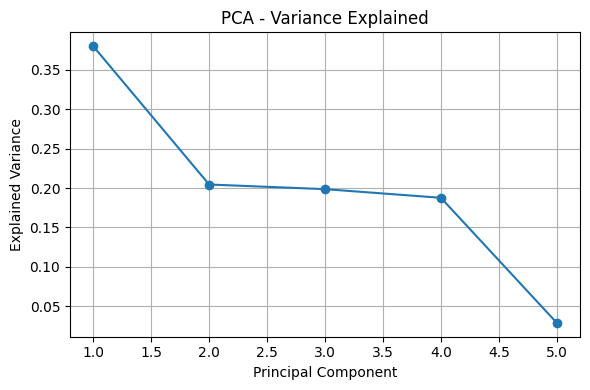

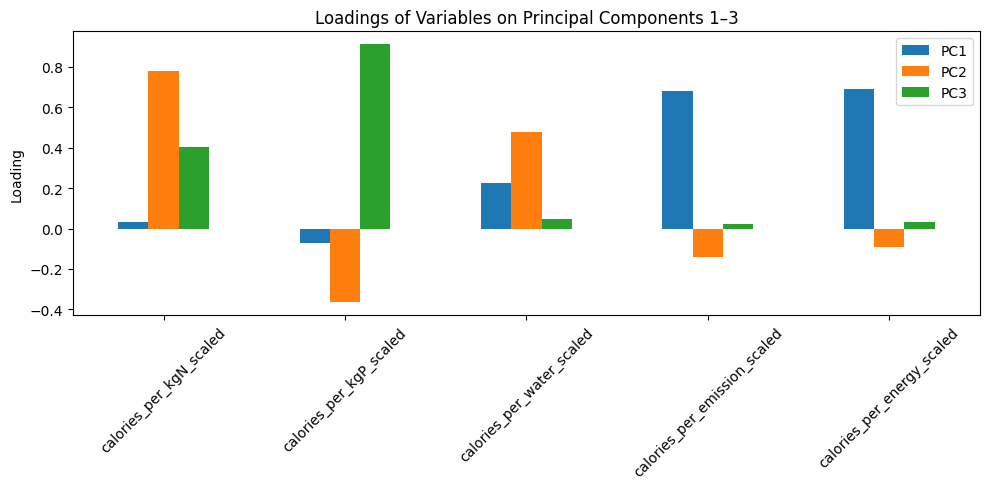

In [69]:
loadings_eff = plot_pca_and_loadings(df_scaled, weights_efficiency)

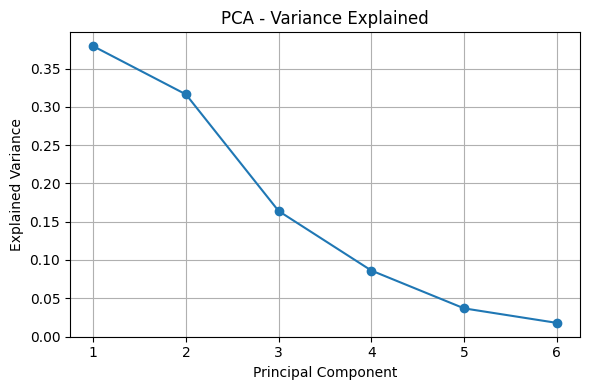

<ipython-input-42-a929d569d72c>:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


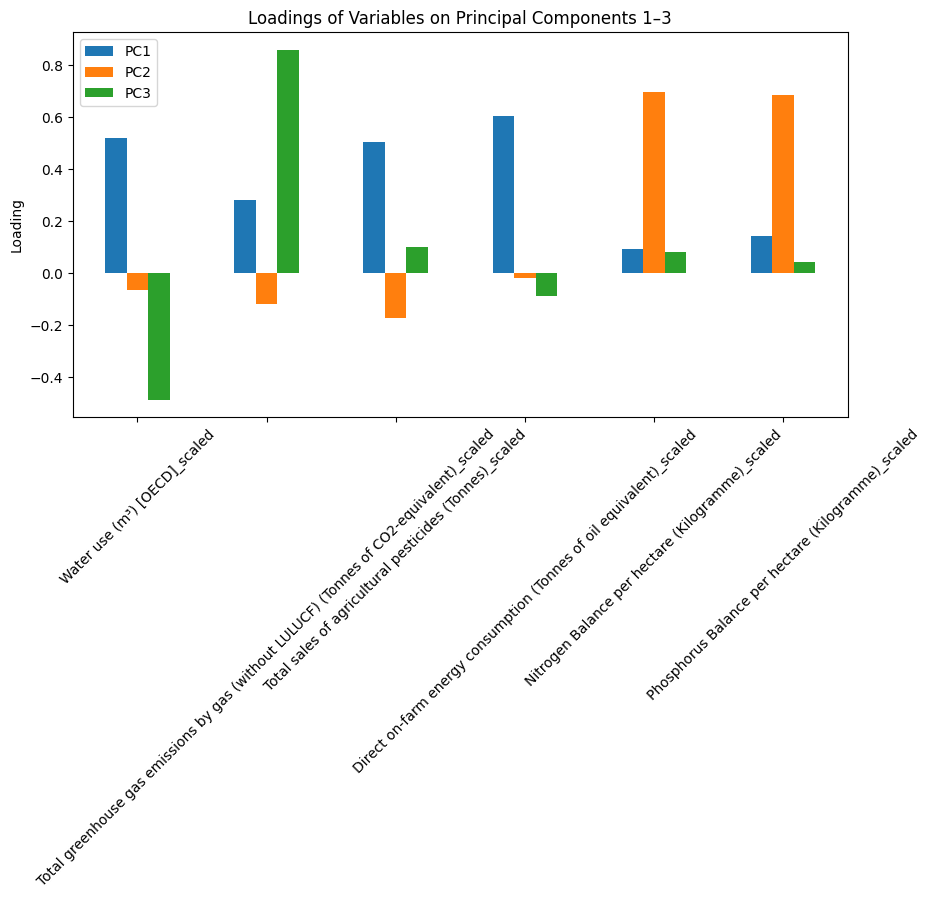

In [70]:
loadings_sust = plot_pca_and_loadings(df_scaled, weights_sustainability)

PCA1 explains must of the variance so we use this to calculate the PCA weighings.

In [71]:
weights_comparison_eff, weights_efficiency = compute_pca_weights(loadings_eff, weights_efficiency)


In [72]:
weights_efficiency = weights_comparison_eff['PCA Weights'].to_dict()
weights_efficiency

{'calories_per_energy_scaled': 0.4076344950614472,
 'calories_per_emission_scaled': 0.4000338295959849,
 'calories_per_water_scaled': 0.1317908562812031,
 'calories_per_kgP_scaled': 0.04091407620166031,
 'calories_per_kgN_scaled': 0.019626742859704425}

Interpretation:
- calories_per_energy_scaled: PCA suggest increasing
- calories_per_emission_scaled: PCA suggests increasing
- calories_er_water_scaled: PCA suggest decreasing
- calories_per_kgP_scaled: PCA suggest decreasing
- calories_per_kgN_scaled: PCA suggests decreasing

Energy and emissions are the biggest factors. They also present the gretest changes recommendations from PCA. Fertilizers changes are not as big.

In [73]:
weights_comparison_sust, weights_sustainability = compute_pca_weights(loadings_sust, weights_sustainability)

In [74]:
weights_sustainability = weights_comparison_sust['PCA Weights'].to_dict()
weights_sustainability

{'Direct on-farm energy consumption (Tonnes of oil equivalent)_scaled': 0.28189298523456446,
 'Water use (m³) [OECD]_scaled': 0.242061053711807,
 'Total sales of agricultural pesticides (Tonnes)_scaled': 0.23490452297893863,
 'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)_scaled': 0.1305587523180492,
 'Phosphorus Balance per hectare (Kilogramme)_scaled': 0.06664788728284984,
 'Nitrogen Balance per hectare (Kilogramme)_scaled': 0.04393479847379083}

Interpretation:
- Direct on-farm energy consumption (Tonnes of oil equivalent)_scaled: PCA suggest increase
- Water use: PCA suggest increase
- Total sales of agricultural pesticides (Tonnes)_scaled: PCA suggests increae
- Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)_scaled: PCA suggests decrease
- Phosphorus Balance per hectare (Kilogramme)_scaled: PCA suggests decrease
- Nitrogen Balance per hectare (Kilogramme)_scaled: PCA suggests decrease

Energy, again is very relevant. However, now emissions are not as relevant for sustaianbility, or at least, they are overweighed. Water and pesticides are relevant too.

### WEIGHTS JUSTIFICATION - DATA-DRIVEN (SENSITIVITY ANALYSIS)

In [75]:
sensitivity_eff_df = run_efficiency_sensitivity(df_scaled, weights_efficiency)

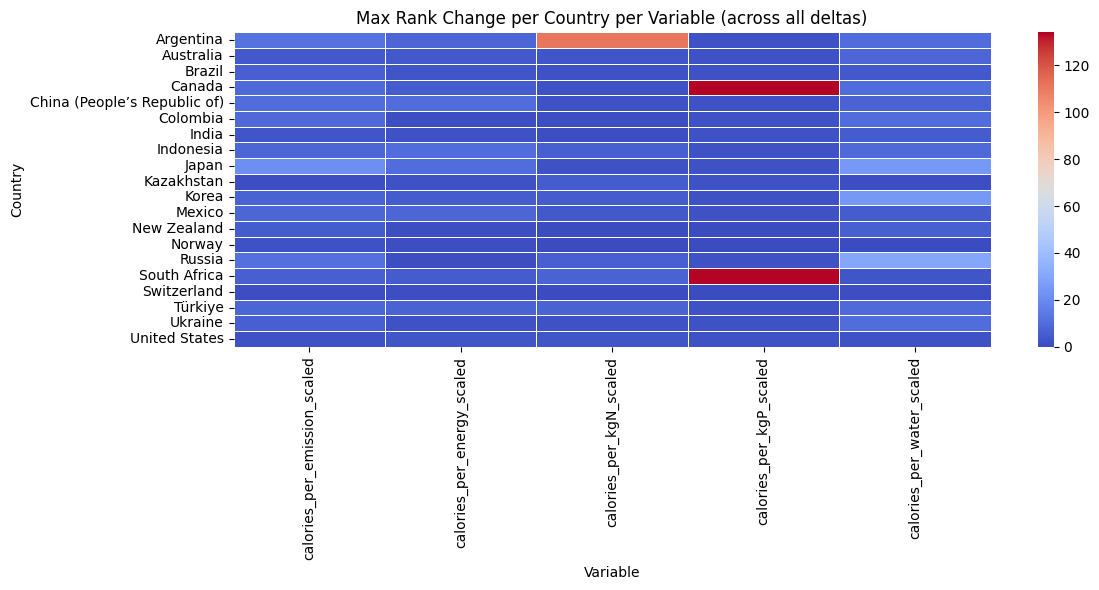

In [76]:
heatmap_data = (
    sensitivity_eff_df .groupby(['Country', 'Variable'])['Rank_Change']
    .max()
    .unstack()
)
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', linewidths=0.5)
plt.title('Max Rank Change per Country per Variable (across all deltas)')
plt.tight_layout()
plt.show()

In [77]:
sensitivity_sust_df = run_efficiency_sensitivity(df_scaled, weights_sustainability)

In [78]:
rename_dict = {
    'Water use (m³) [OECD]_scaled': 'Water use',
    'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)_scaled': 'GHG emissions',
    'Total sales of agricultural pesticides (Tonnes)_scaled': 'Pesticides',
    'Direct on-farm energy consumption (Tonnes of oil equivalent)_scaled': 'Energy use',
    'Nitrogen Balance per hectare (Kilogramme)_scaled': 'N Balance',
    'Phosphorus Balance per hectare (Kilogramme)_scaled': 'P Balance',
    'calories_per_kgN_scaled': 'cal/kgN',
    'calories_per_kgP_scaled': 'cal/kgP',
    'calories_per_water_scaled': 'cal/water',
    'calories_per_emission_scaled': 'cal/CO2',
    'calories_per_energy_scaled': 'cal/energy'
}

sensitivity_sust_df['Variable'] = sensitivity_sust_df['Variable'].replace(rename_dict)
sensitivity_eff_df['Variable'] = sensitivity_eff_df['Variable'].replace(rename_dict)

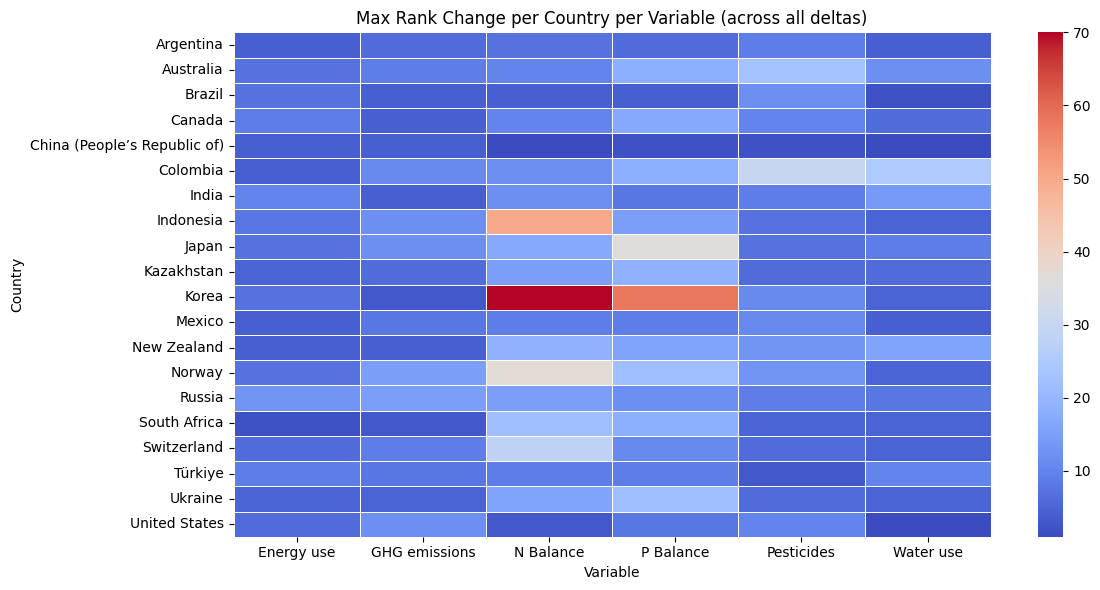

In [79]:
heatmap_data = (
    sensitivity_sust_df .groupby(['Country', 'Variable'])['Rank_Change']
    .max()
    .unstack()
)
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', linewidths=0.5)
plt.title('Max Rank Change per Country per Variable (across all deltas)')
plt.tight_layout()
plt.show()

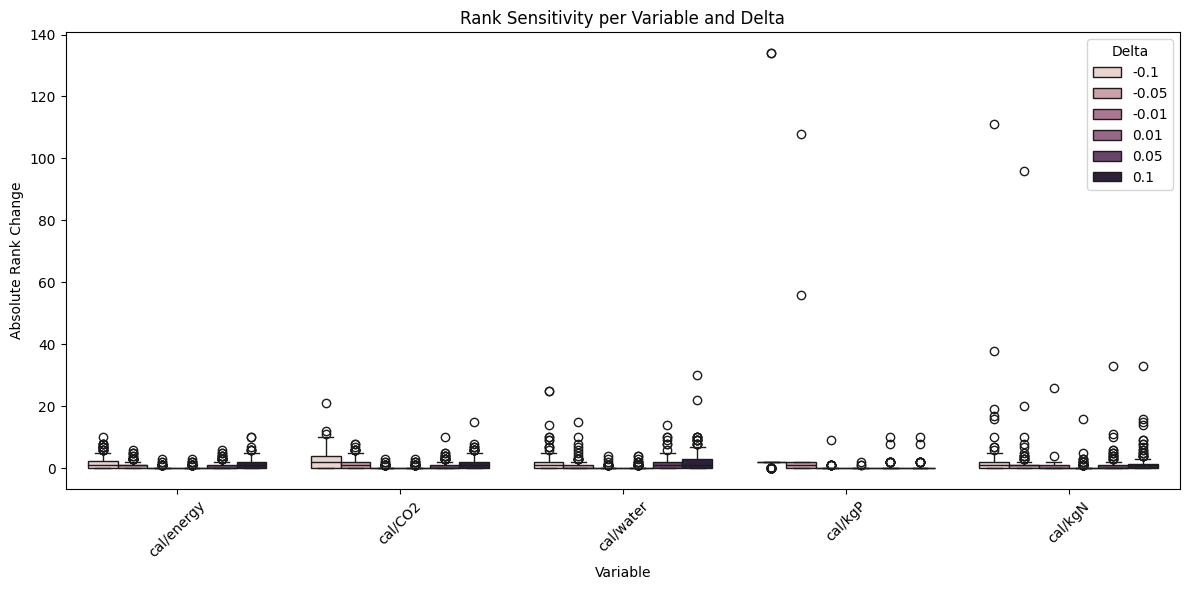

In [80]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=sensitivity_eff_df, x='Variable', y='Rank_Change', hue='Delta')
plt.title('Rank Sensitivity per Variable and Delta')
plt.ylabel('Absolute Rank Change')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Emissions and energy are the most sensitive. -> highest weighings.

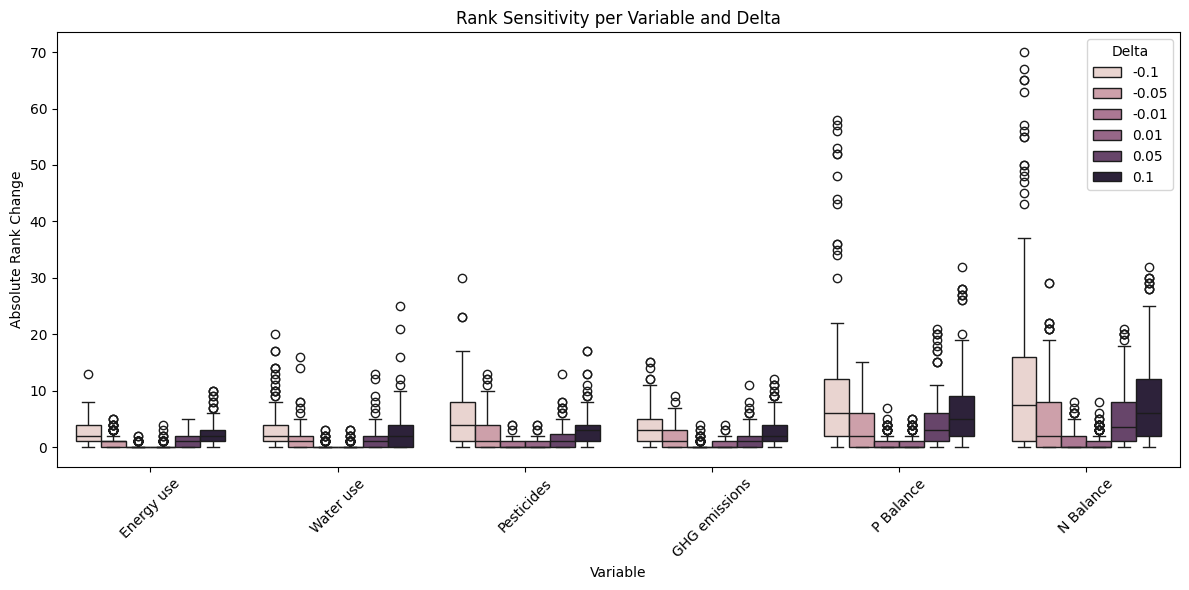

In [81]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=sensitivity_sust_df, x='Variable', y='Rank_Change', hue='Delta')
plt.title('Rank Sensitivity per Variable and Delta')
plt.ylabel('Absolute Rank Change')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The higher N balance recommendation does contract the decrease recommendation by PCA. However, given the global urgency around climate change and the EU’s prioritization of carbon neutrality we kept the highest score to be the one of GHG emissions.

### SCORES WITH UPDATED WEIGHTS

Below we are just applying the algorithm we had used previously.

In [82]:
# Clone the scaled DataFrame
df_scaled_updated = df_scaled.copy()

# Step 1: Compute efficiency score using weighted sum
df_scaled_updated['efficiency_score'] = df_scaled_updated[list(weights_efficiency.keys())].dot(
    pd.Series(weights_efficiency)
)

# Step 2: Compute resource pressure index (lower is better)
df_scaled_updated['resource_pressure_index'] = df_scaled_updated[list(weights_sustainability.keys())].dot(
    pd.Series(weights_sustainability)
)

# Step 3: Compute sustainability score as output/input
df_scaled_updated['sustainability_score'] = (
    df_scaled_updated['calories_scaled'] / (df_scaled_updated['resource_pressure_index'] + 1e-6)
)

# Step 4: Normalize sustainability score to [0, 1]
df_scaled_updated['sustainability_score'] = scaler.fit_transform(
    df_scaled_updated[['sustainability_score']]
)

In [83]:
# save data
df_scaled_updated.to_csv("/content/scores_updated.csv", index=False)

### VISUALISATIONS

In [84]:
# Prepare your data
df = df_scaled_updated.copy()

# Create and display Sustainability animation
fig_sus = create_animated_bar_chart(
    df,
    value_col='sustainability_score',
    title="🌱 Sustainability Score of 20 Countries Over Time (Shaded Green by Score)",
    color_map='Greens',
    label="Sustainability Score"
)
fig_sus.show()

# Create and display Efficiency animation
fig_eff = create_animated_bar_chart(
    df,
    value_col='efficiency_score',
    title="⚙️ Efficiency Score of 20 Countries Over Time (Shaded Blue by Score)",
    color_map='Blues',
    label="Efficiency Score"
)
fig_eff.show()

<ipython-input-46-c64047b18987>:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(color_map)


<ipython-input-46-c64047b18987>:24: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [85]:
# --- Paths & Constants ---
FLAG_PATH = "/Users/menciaizaga/Desktop/flags/"
df = df_scaled_updated.copy()

# Country flag codes
country_code_map = {
    'Argentina': 'ar', 'Australia': 'au', 'Brazil': 'br', 'Canada': 'ca',
    'China (People’s Republic of)': 'cn', 'Colombia': 'co', 'India': 'in',
    'Indonesia': 'id', 'Japan': 'jp', 'Kazakhstan': 'kz', 'Korea': 'kr',
    'Mexico': 'mx', 'New Zealand': 'nz', 'Norway': 'no', 'Russia': 'ru',
    'South Africa': 'za', 'Switzerland': 'ch', 'Türkiye': 'tr',
    'Ukraine': 'ua', 'United States': 'us'
}

# Sustainability & efficiency component weights
resource_components = {
    'Energy': 0.2819, 'Water': 0.2421, 'Pesticides': 0.2349,
    'Emissions': 0.1306, 'Phosphorus': 0.0666, 'Nitrogen': 0.0439
}

efficiency_components = {
    'Nitrogen': 0.0196, 'Phosphorus': 0.0409, 'Water': 0.1318,
    'Emissions': 0.4000, 'Energy': 0.4076
}

# --- Interactive Widgets ---
years_sorted = sorted(df['Year'].unique())
play = widgets.Play(value=0, min=0, max=len(years_sorted) - 1, step=1, interval=1000, description="Play")
slider = widgets.SelectionSlider(options=years_sorted, value=years_sorted[0], description='Year:', layout=widgets.Layout(width='50%'), continuous_update=False)
widgets.jslink((play, 'value'), (slider, 'index'))

# --- Layout Display ---
display(Markdown("## Step 1: Select a year"))
display(HBox([play, slider]))

buttons_output = widgets.Output()
pie_output = widgets.Output()

display(Markdown("## Step 2: Select a country"))
display(buttons_output)

display(Markdown("## Step 3: Score breakdown"))
display(pie_output)

selected_country = {'value': None}

# --- Update Country Flag Buttons ---
def update_all(change=None):
    year = slider.value
    df_filtered = df[df['Year'] == year]
    countries = sorted(df_filtered['Country'].unique())

    with buttons_output:
        clear_output(wait=True)
        button_boxes = []

        for country in countries:
            code = country_code_map.get(country)
            img_html = f'<img src="flags/{code}.png" width="32" style="vertical-align:middle;">' if code else ''
            flag_widget = HTML(value=img_html)

            button = widgets.Button(
                description=country, tooltip=country,
                layout=widgets.Layout(width='140px', height='40px'),
                style=dict(button_color='#f7f7f7')
            )
            button.on_click(lambda b, c=country: update_country(c, year))
            button_boxes.append(VBox([flag_widget, button], layout=widgets.Layout(align_items='center')))

        grid = GridBox(button_boxes, layout=widgets.Layout(grid_template_columns="repeat(5, 160px)", grid_gap="10px"))
        display(grid)

    with pie_output:
        clear_output(wait=True)
        print("Select a country above to see score breakdowns.")

# --- Update Pie Charts on Country Selection ---
def update_country(country, year):
    global fig_weights
    selected_country['value'] = country
    row = df[(df['Country'] == country) & (df['Year'] == year)].iloc[0]

    # Extract weighted values
    sust_keys = [
        'Direct on-farm energy consumption (Tonnes of oil equivalent)_scaled',
        'Water use (m³) [OECD]_scaled',
        'Total sales of agricultural pesticides (Tonnes)_scaled',
        'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)_scaled',
        'Phosphorus Balance per hectare (Kilogramme)_scaled',
        'Nitrogen Balance per hectare (Kilogramme)_scaled'
    ]
    eff_keys = [
        'calories_per_kgN_scaled',
        'calories_per_kgP_scaled',
        'calories_per_water_scaled',
        'calories_per_emission_scaled',
        'calories_per_energy_scaled'
    ]
    sust_vals = [row[k] for k in sust_keys]
    eff_vals = [row[k] for k in eff_keys]

    fig_weights = make_subplots(rows=1, cols=2, specs=[[{'type': 'domain'}, {'type': 'domain'}]])

    fig_weights.add_trace(go.Pie(
        labels=list(resource_components.keys()),
        values=[v * w for v, w in zip(sust_vals, resource_components.values())],
        hole=0.4, name='Sustainability'
    ), row=1, col=1)

    fig_weights.add_trace(go.Pie(
        labels=list(efficiency_components.keys()),
        values=[v * w for v, w in zip(eff_vals, efficiency_components.values())],
        hole=0.4, name='Efficiency'
    ), row=1, col=2)

    fig_weights.update_layout(
        width=1100, height=480,
        margin=dict(t=100, l=30, r=30, b=40),
        annotations=[
            dict(text=f"Sustainability — {country} ({year})", x=0.20, y=1.15, xref='paper', yref='paper', showarrow=False, font=dict(size=16)),
            dict(text=f"Efficiency — {country} ({year})", x=0.80, y=1.15, xref='paper', yref='paper', showarrow=False, font=dict(size=16))
        ],
        legend=dict(font=dict(size=10), orientation='v', x=1.05, y=0.5)
    )

    with pie_output:
        clear_output(wait=True)
        display(fig_weights)

# --- Initialize ---
slider.observe(update_all, names='value')
update_all()

## Step 1: Select a year

## Step 2: Select a country

Output()

## Step 3: Score breakdown

Output()

Since we cannot add the dashboard to the presentation, we can just plot the pie charts for each country as a function of time.

In [86]:
!pip install --upgrade kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.1 MB/s eta 0:00:00


In [87]:
sustainability_components = {
    'Energy': ('Direct on-farm energy consumption (Tonnes of oil equivalent)_scaled', 0.2818929852345645),
    'Water': ('Water use (m³) [OECD]_scaled', 0.24206105371180747),
    'Pesticides': ('Total sales of agricultural pesticides (Tonnes)_scaled', 0.23490452297893852),
    'Emissions': ('Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)_scaled', 0.13055875231804911),
    'Phosphorus': ('Phosphorus Balance per hectare (Kilogramme)_scaled', 0.06664788728284966),
    'Nitrogen': ('Nitrogen Balance per hectare (Kilogramme)_scaled', 0.043934798473970726)
}

generate_pie_animation(
    df_scaled_updated,
    components=sustainability_components,
    title="Country Sustainability Pie Charts Over Time",
    output_path="sustainability_pie_evolution.html"
)

'sustainability_pie_evolution.html'

In [88]:
efficiency_components = {
    'Nitrogen': ('calories_per_kgN_scaled', 0.01962674285970439),
    'Phosphorus': ('calories_per_kgP_scaled', 0.04091407620166069),
    'Water': ('calories_per_water_scaled', 0.13179085628120332),
    'Emissions': ('calories_per_emission_scaled', 0.4000338295959846),
    'Energy': ('calories_per_energy_scaled', 0.40763449506144706)
}

generate_pie_animation(
    df_scaled_updated,
    components=efficiency_components,
    title="Country Efficiency Pie Charts Over Time",
    output_path="efficiency_pie_evolution.html"
)

'efficiency_pie_evolution.html'

### RECCOMENDATION ANALYSIS COMMODITIES

In [89]:
crops_url = "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ATM,DSD_AGR@DF_OUTLOOK_2021_2030,1.0/.A....?endPeriod=2030&dimensionAtObservation=AllDimensions&format=json"

In [90]:
crops = fetch_oecd_data(crops_url)

In [91]:
# Pivot so each measure is its own column
wide = (crops
    .pivot_table(
        index=['Reference area','Time period','Commodity'],
        columns='Measure',
        values='value',
        aggfunc='first'
    )
    .reset_index()
)

# Subset to the features you care about:
features = [
    'Production',
    'Direct GHG emission',
    'Producer price',
    'Area harvested',
    'Yield'
]
X = wide[features].copy()

In [92]:
imp = SimpleImputer(strategy='mean')
X_imp = imp.fit_transform(X)
scaler = StandardScaler()
X_std = scaler.fit_transform(X_imp)

In [93]:
pca = PCA(n_components=5)
pca.fit(X_std)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.314376   0.21695064 0.19934155 0.18883036 0.08050145]


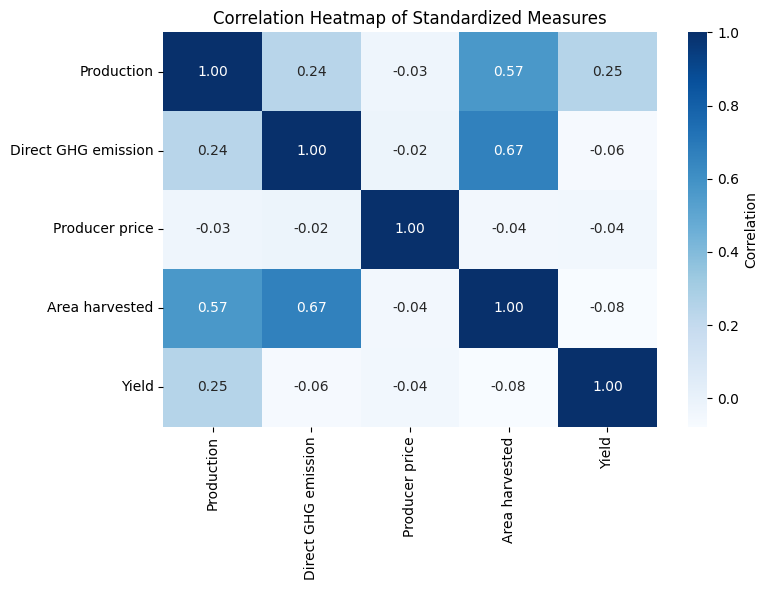

In [94]:
features = ["Production", "Direct GHG emission", "Producer price", "Area harvested", "Yield"]
X = wide[features].copy()
scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X), columns=features)
corr = X_std.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Heatmap of Standardized Measures")
plt.tight_layout()
plt.show()

In [95]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(len(features))]
)
loadings

,PC1,PC2,PC3,PC4,PC5
Production,0.701470,0.150814,0.070056,-0.082173,0.688139
Direct GHG emission,0.225543,-0.399347,-0.180516,0.869862,-0.020140
Producer price,-0.052603,-0.175527,0.973667,0.135325,0.009126
Area harvested,0.645026,-0.292597,0.031095,-0.309791,-0.633554
Yield,0.195563,0.837469,0.116242,0.349719,-0.352966


In [96]:
pc1 = loadings['PC1'].abs()
weights = pc1 / pc1.sum()
print("Data-driven weights:", weights.to_dict())

Data-driven weights: {'Production': 0.38537942368043165, 'Direct GHG emission': 0.12391092661996837, 'Producer price': 0.028899743703280037, 'Area harvested': 0.3543695974431979, 'Yield': 0.10744030855312199}


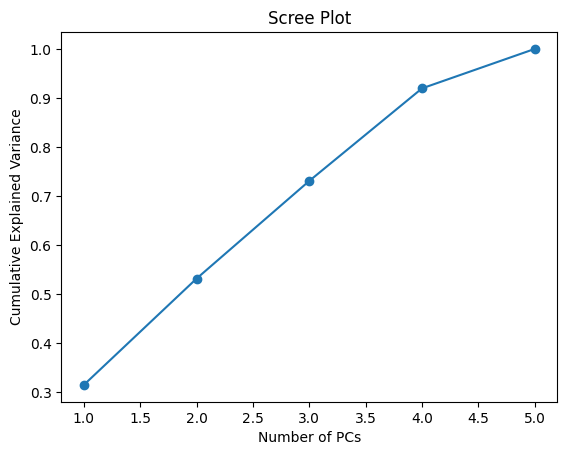

In [97]:
plt.plot(
    range(1, len(features)+1),
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.show()


In [98]:
crops = crops.rename(columns={
    'Reference area':     'country',
    'Commodity':    'commodity',
    'Measure':'measure',
    'Time period':  'year'
})
crops['year'] = crops['year'].astype(int)

subset_df = crops[crops['measure'].isin(['Production', 'Direct GHG emission','Producer price', 'Area harvested','Yield'])]

wide = (subset_df
        .pivot_table(
            index=['country','year','commodity'],
            columns='measure',
            values='value',
            aggfunc='first')
        .reset_index()
        .fillna(0))
wide.head(10)
eps = 1e-6

def normalize(series, eps=1e-6):
    mn, mx = series.min(), series.max()
    return (series - mn + eps) / (mx - mn + eps)

wide["nghg"]     = 1 - normalize(wide["Direct GHG emission"])
wide["nharvest"] = 1 - normalize(wide["Area harvested"])
wide["nprice"]   = 1 - normalize(wide["Producer price"])

wide["input_efficiency_score"] = (
      weights["Direct GHG emission"] * wide["nghg"]
    + weights["Area harvested"] * wide["nharvest"]
    + weights["Producer price"] * wide["nprice"]
)

wide["output_score"]      = normalize(wide["Yield"])

wide["efficiency_score"] = wide["output_score"] * wide["input_efficiency_score"]

wide["sus_raw"] = (weights["Production"] * wide["Production"]) / (weights["Direct GHG emission"] * wide["Direct GHG emission"] + eps)

wide["sus_log"] = np.log1p(wide["sus_raw"])

wide["sustainability_score"] = normalize(wide["sus_log"])


commodity_scores = (
    wide
    .groupby("commodity")[["efficiency_score", "sustainability_score"]]
    .sum()
    .sort_values("efficiency_score", ascending=False)
)

commodity_scores["efficiency_score"]     /= commodity_scores["efficiency_score"].sum()
commodity_scores["sustainability_score"] /= commodity_scores["sustainability_score"].sum()
commodity_scores.head(10)

measure,efficiency_score,sustainability_score
commodity,,
Sugar cane,0.453772,0.023665
Sugar beet,0.266958,0.020743
Maize (corn),0.051776,0.024482
Roots and tubers,0.050359,0.027250
Raw milk,0.032736,0.022584
Rice,0.031506,0.017859
Wheat,0.029448,0.023807
Other coarse grains,0.025474,0.025157
Soya beans,0.017557,0.023613


In [99]:
commodity_scores.to_csv("commodity_scores.csv", index=True)

In [100]:
commodity_scores = pd.read_csv("commodity_scores.csv")
commodity_scores

,commodity,efficiency_score,sustainability_score
0,Sugar cane,4.537722e-01,2.366506e-02
1,Sugar beet,2.669581e-01,2.074345e-02
2,Maize (corn),5.177647e-02,2.448185e-02
3,Roots and tubers,5.035883e-02,2.724984e-02
4,Raw milk,3.273576e-02,2.258392e-02
5,Rice,3.150567e-02,1.785937e-02
6,Wheat,2.944848e-02,2.380674e-02
7,Other coarse grains,2.547415e-02,2.515730e-02
8,Soya beans,1.755658e-02,2.361301e-02
9,Other oilseeds,1.693253e-02,2.567030e-02


In [101]:

highest_production = wide.loc[wide.groupby(['country', 'year'])['Production'].idxmax()]
highest_production = highest_production[['country', 'year', 'Production', 'commodity']]
highest_production

measure,country,year,Production,commodity
35,Africa,1990,6.789131e+04,Sugar cane
75,Africa,1991,7.143198e+04,Sugar cane
115,Africa,1992,6.209081e+04,Sugar cane
155,Africa,1993,6.015664e+04,Sugar cane
195,Africa,1994,6.833072e+04,Sugar cane
...,...,...,...,...
75275,World,2026,1.882647e+06,Sugar cane
75315,World,2027,1.899180e+06,Sugar cane
75355,World,2028,1.917142e+06,Sugar cane
75395,World,2029,1.936364e+06,Sugar cane


In [102]:
category_map = {
    # Meats
    'Beef and veal': 'Meat',
    'Pigmeat': 'Meat',
    'Poultry meat': 'Meat',
    'Sheepmeat': 'Meat',

    # Dairy
    'Butter and other fats and oils derived from milk': 'Dairy',
    'Casein': 'Dairy',
    'Cheese, fresh or processed': 'Dairy',
    'Fresh dairy products': 'Dairy',
    'Raw milk': 'Dairy',
    'Skim milk powder': 'Dairy',
    'Whole milk powder': 'Dairy',
    'Whey powder': 'Dairy',
    'Eggs, in shell, preserved or cooked': 'Dairy',

    # Sugars
    'Raw cane or beet sugar': 'Sugar',
    'Refined sugar': 'Sugar',
    'Molasses': 'Sugar',
    'Sugar and molasses': 'Sugar',
    'Sugar beet': 'Sugar',
    'Sugar cane': 'Sugar',
    'Glucose and glucose syrup; fructose and fructose syrup; lactose and lactose syrup; invert sugar; sugars and sugar syrups n.e.c.; artificial honey; caramel': 'Sugar',

    # Oils
    'Vegetable oils': 'Oils',
    'Cottonseed': 'Oils',
    'Fats and oils and their fractions, of fish, other than liver oils': 'Oils',

    # Grains & Cereals
    'Maize (corn)': 'Cereals',
    'Rice': 'Cereals',
    'Wheat': 'Cereals',
    'Other coarse grains': 'Cereals',
    'Flours and meals of oil seeds or oleaginous fruits, except those of mustard': 'Cereals',

    # Oilseeds (non‐edible)
    'Soya beans': 'Oilseeds',
    'Other oilseeds': 'Oilseeds',

    # Legumes & Roots
    'Pulses (dried leguminous vegetables)': 'Legumes',
    'Roots and tubers': 'Roots',

    # Fish and Aquatic
    'Fish from capture': 'Fish',
    'Fish from aquaculture': 'Fish',
    'Fish and other fishing products': 'Fish',
    'Edible fish meal': 'Fish',

    # Industrial / Bio-based
    'Biodiesel': 'Industrial',
    'Ethanol': 'Industrial',
    'Distiller\'s dry grains': 'Industrial',

    # Byproducts or Unclear
    'Agricultural commodities': 'Other'
}

In [103]:
highest_production['category'] = highest_production['commodity'].map(category_map)
highest_production['category'] = highest_production['category'].fillna('Other')
commodity_scores["category"] = commodity_scores["commodity"].map(category_map).fillna("Other")

In [104]:
df_scaled_updated_scores  = df_scaled_updated[['Country', 'Year', 'sustainability_score', 'efficiency_score']].copy()

In [105]:
# Renaming
highest_production = highest_production.rename(columns={
    'country': 'Country',
    'year': 'Year',
    'Commodity': 'Commodity',
    'Production (Tonnes)': 'Production (Tonnes)'
})

In [106]:
# Apply category mapping with default 'Other'
commodity_scores["category"] = commodity_scores["commodity"].map(category_map).fillna("Other")

In [107]:
# Group by category and compute mean of both scores
category_scores_df = commodity_scores.groupby("category")[["efficiency_score", "sustainability_score"]].mean().reset_index()
category_scores_df

,category,efficiency_score,sustainability_score
0,Cereals,2.764096e-02,2.918794e-02
1,Dairy,3.637315e-03,1.694163e-02
2,Fish,1.002134e-08,4.641201e-02
3,Industrial,1.002539e-08,2.892009e-02
4,Legumes,1.502711e-02,2.613450e-02
5,Meat,1.577042e-04,1.658054e-02
6,Oils,2.607680e-03,3.411485e-02
7,Oilseeds,1.724455e-02,2.464165e-02
8,Other,9.831925e-09,2.669668e-09
9,Roots,5.035883e-02,2.724984e-02


In [108]:
scores_and_production = pd.merge(
    df_scaled_updated_scores,
    highest_production,
    on=['Country', 'Year'],
    how='left'
)

In [109]:
scores_and_production

,Country,Year,sustainability_score,efficiency_score,Production,commodity,category
0,Argentina,2012,0.076689,0.077906,49353.000,Soya beans,Oilseeds
1,Argentina,2013,0.074357,0.073584,53400.000,Soya beans,Oilseeds
2,Argentina,2014,0.076701,0.074842,61400.000,Soya beans,Oilseeds
3,Argentina,2015,0.083798,0.053776,58800.000,Soya beans,Oilseeds
4,Argentina,2016,0.087020,0.056512,55000.000,Soya beans,Oilseeds
...,...,...,...,...,...,...,...
175,United States,2016,0.059425,0.019808,384789.496,Maize (corn),Cereals
176,United States,2017,0.096946,0.019797,370970.808,Maize (corn),Cereals
177,United States,2018,0.096627,0.019715,364264.680,Maize (corn),Cereals
178,United States,2019,0.098789,0.019805,345975.240,Maize (corn),Cereals


In [110]:
scores_and_production["category"].unique(), highest_production["category"].unique(), commodity_scores["category"].unique()

(array(['Oilseeds', 'Cereals', 'Sugar', 'Oils', 'Dairy', 'Fish'],
       dtype=object),
 array(['Sugar', 'Roots', 'Oilseeds', 'Cereals', 'Fish', 'Dairy', 'Meat',
        'Oils'], dtype=object),
 array(['Sugar', 'Cereals', 'Roots', 'Dairy', 'Oilseeds', 'Legumes',
        'Oils', 'Meat', 'Fish', 'Industrial', 'Other'], dtype=object))

In [111]:
# Step 1: Set index for lookup
category_scores_df_indexed = category_scores_df.set_index("category")

# Step 2: Create label mapping with scores
category_label_map = {
    cat: f"{cat} (⚙️ {row['efficiency_score']:.3f}, 🌱 {row['sustainability_score']:.3f})"
    for cat, row in category_scores_df_indexed.iterrows()
}

# Step 3: Apply to dataset
scores_and_production = scores_and_production.copy()
scores_and_production['category_label'] = scores_and_production['category'].map(category_label_map)

# Step 4: Plot
fig = px.bar(
    scores_and_production,
    x='Year',
    y='Production',
    color='category_label',
    facet_col='Country',
    facet_col_wrap=5,
    hover_data=['commodity', 'sustainability_score', 'efficiency_score'],
    title='Top Commodity by Production',
    labels={'Production': 'Top Production Value'}
)

# Step 5: Layout tweaks
fig.update_layout(
    height=950,
    title_x=0.5,
    font=dict(size=12),  # Axis and tick font size
    margin=dict(t=60, b=160),  # Less bottom margin now
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.20,
        xanchor="left",    # ⬅️ was 'center', now align left
        x=-0.06,             # ⬅️ was 0.5 (center), now full LHS
        title=None,
        font=dict(size=14),
        itemwidth=200,
        tracegroupgap=10
    )
)

# Step 6: Independent Y
fig.update_yaxes(matches=None)

# Step 7: Clean facet titles
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1].strip()))

Integrating a World map that defined the Countries that Produce the Top 10 sustainable crops, with the bar plot above

In [144]:

# --- Prereqs: wide, best, emoji_map, exclude_countries already defined below ---

# Defining the Helper functions

# Helper to get ISO3
def iso3(name):
    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return None
# Helper for flag emoji
def country_flag(name):
    try:
        code = pycountry.countries.lookup(name).alpha_2
        return ''.join(chr(ord(c)+127397) for c in code)
    except:
        return ''

# 2. Emoji map for categories
emoji_map = {
    'Meat':           '🥩',
    'Dairy':          '🥛',
    'Sugar':          '🍬',
    'Oils':           '🛢️',
    'Cereals':        '🌾',
    'Oilseeds':       '🌰',
    'Biofuels':       '⛽',
    'DistillerGrains':'🌽',
    'Fish':           '🐟',
    'Pulses':         '🥜',
    'Roots':    '🥔'
}

exclude_countries = {
    'World', 'OECD', 'Developed countries', 'Developing countries',
    'European Union', 'EU', 'Africa', 'Asia', 'Americas', 'Latin America','Europe','Northern America','Oceania'
}
# Compute mean sustainability per category
category_sus = (
    wide
    .groupby('category')['sustainability_score']
    .mean()
    .sort_values(ascending=False)
)
# For each year and country, pick the category (in top10) with max Production
# Select the top 10 categories
top10 = category_sus.head(10).index.tolist()
#print("Top 10 sustainable categories:", top10)
wide['category'] = wide['commodity'].map(category_map)

#print(wide.head(10))
mask = wide['category'].isin(top10)
# 2. Map into a new column
# finding the trop prodcuer of each sustainable category
top_prod = (
    wide[mask]
    .groupby(['year','country','category'])['Production']
    .sum()
    .reset_index()
)

best = (
    top_prod
    .sort_values(['year','country','Production'], ascending=[True,True,False])
    .groupby(['year','country'])
    .first()
    .reset_index()  # has columns year, country, category, Production
)

# Apply your existing category_map
wide['category'] = wide['commodity'].map(category_map)


# 1) Prepare the data
wide['country'] = wide['country'].replace({
    'Iran':    'Iran, Islamic Republic of',
    'Russia':  'Russian Federation',
    'Turkey':  'Türkiye',
    'Viet Nam':'Vietnam'
})
demog = wide[~wide['country'].isin(exclude_countries)]
yearly = (
    demog.groupby(['year','country'])['sustainability_score']
         .mean().reset_index()
)
yearly['iso3'] = yearly['country'].map(iso3)
# 1. For each year and country, pick the category (in top10) with max Production
mask = wide['category'].isin(top10)


In [145]:
lookup = {}
for yr in yearly['year'].unique():
    dfb = best[best['year'] == yr]
    # Ensure emoji_map covers all categories
    for cat in dfb['category'].unique():
        if cat not in emoji_map:
            emoji_map[cat] = emoji_map.get('RootsTubers', '❓')
    lookup[yr] = {
        'countries': dfb['country'].tolist(),
        'emojis': [f"{country_flag(c)}{emoji_map[cat]}" for c, cat in zip(dfb['country'], dfb['category'])]
    }

# Create frames
map_frames = []
for yr in sorted(yearly['year'].unique()):
    dfy = yearly[yearly['year'] == yr]
    cs, em = lookup[yr]['countries'], lookup[yr]['emojis']
    map_frames.append(go.Frame(
        name=str(yr),
        data=[
            go.Choropleth(
                locations=dfy['iso3'],
                z=dfy['sustainability_score'].clip(0, 0.8),
                zmin=0, zmax=0.8,
                colorscale='RdYlGn',
                marker_line_color='white',
                showscale=True,
                colorbar=dict(
                    orientation='h', x=0.5, y=-0.12,
                    xanchor='center', len=0.6, thickness=10,
                    tickvals=[0, 0.8], ticktext=['🔥', '🌱'], ticks='outside'
                )
            ),
            go.Scattergeo(
                locations=cs,
                locationmode='country names',
                text=em,
                mode='text',
                textfont=dict(size=16)
            )
        ],
        layout=go.Layout(
            title=dict(text=str(yr), x=0.5, font=dict(size=24)),
            geo=dict(
                domain=dict(x=[0, 1], y=[0.1, 1]),
                projection_type='equirectangular',
                showland=True, landcolor='rgb(240,240,240)',
                showocean=True, oceancolor='#55b5ff',
                showcountries=True, countrycolor='white',
                showsubunits=True, subunitcolor='lightgray',
                showcoastlines=True, coastlinecolor='gray'
            )
        )
    ))

fig_map = go.Figure(
    data=map_frames[0].data,
    frames=map_frames
)
fig_map.update_layout(
    width=800, height=400,
    margin=dict(l=0, r=0, t=50, b=0),
    title_text="🌍 Top Sustainable Crops by Country 🏆",
    title_x = 0.5,
    showlegend=False,
    updatemenus=[dict(
        type='buttons', showactive=False,
        x=0.5, y=0.05,
        buttons=[dict(
            label='Play',
            method='animate',
            args=[None, {
                "frame": {"duration": 800, "redraw": True},
                "transition": {"duration": 0},
                "fromcurrent": True,
                "mode": "immediate"
            }]
        )]
    )]
)

# --- Build the bar chart figure ---

# Prepare labels with emojis
category_scores_df_indexed = category_scores_df.set_index("category")
category_label_map = {
    cat: f"{emoji_map.get(cat, '')} {cat} (⚙️ {row['efficiency_score']:.3f}, 🌱 {row['sustainability_score']:.3f})"
    for cat, row in category_scores_df_indexed.iterrows()
}

scores_and_production = scores_and_production.copy()
scores_and_production['category_label'] = scores_and_production['category'].map(category_label_map)

fig_bar = px.bar(
    scores_and_production,
    x='Year',
    y='Production',
    color='category_label',
    facet_col='Country',
    facet_col_wrap=5,
    hover_data=['commodity', 'sustainability_score', 'efficiency_score'],
    title='Top Commodity by Production',
    labels={'Production': 'Top Production Value'}
)

fig_bar.update_layout(
    height=950,
    title_x=0.5,
    font=dict(size=12),
    margin=dict(t=60, b=160),
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.20,
        xanchor="left", x=-0.06,
        title=None,
        font=dict(size=14),
        itemwidth=200,
        tracegroupgap=10
    )
)
fig_bar.update_yaxes(matches=None)
fig_bar.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1].strip()))
# 1) Make sure the barplot has an explicit width
fig_bar.update_layout(width=1000)

# 2) Reuse that same width for the map
fig_map.update_layout(width=fig_bar.layout.width)

# # --- Display both figures ---
fig_map.show()
fig_bar.show()



### SAVING IMAGES FOR DATA OBSERVATORY

In [146]:
fig.write_html("top_commodity_by_production.html", full_html=True, include_plotlyjs="cdn")
fig_sus.write_html("fig_sus.html")
fig_sus.write_html("fig_eff.html")
fig.write_html("sustainability_map.html")